# Day1: 딥러닝 이해와 실습

## 학습 내용
1. Perceptron의 이해
2. 활성화 함수의 이해
3. Fully connected layer 구현
4. Convolutional neural network 구현

In [93]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image

# Deep learning library
import torch
from torch import nn, optim
import torch.nn.functional as F
from torchvision import datasets, transforms

In [54]:
# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (4,4)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True
plt.rcParams["grid.linestyle"] = ":"

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

# 넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)

## 1. 퍼셉트론 (Perceptron)

### 단일노드 퍼셉트론 함수 구현

In [ ]:
def perceptron(x, nodes = 1):
    if not isinstance(x, np.ndarray):
        raise TypeError("Input must be a NumPy array.")
    if x.ndim < 2:
        x = x[np.newaxis, :]
    m, n = x.shape 

    ## 초기화
    w = np.random.randn(nodes, n) # 표준 정규분포
    b = np.random.rand(nodes, 1) # 균일분포

    y = np.sum(w*x, 1) + b
    return y, w, b

x = np.array([1, 2, 3]) 

output, w, b = perceptron(x)

print("input = \n", x)
print("\noutput = \n", output)
print("\nw = \n", w)
print("\nb = \n", b)


input = 
 [1 2 3]

output = 
 [2.7817]

w = 
 [[ 1.0006  0.9763 -0.2189]]

b = 
 [0.4851]


### 다중노드 퍼셉트론 함수 구현

In [ ]:
def perceptron(x, nodes = 1):
    if not isinstance(x, np.ndarray):
        raise TypeError("Input must be a NumPy array.")
    if x.ndim < 2:
        x = x[np.newaxis, :] 
    m, n = x.shape 

    w = np.random.randn(nodes, n)
    b = np.random.rand(nodes, 1)

    y = np.dot(w, x.T) + b # 행렬 곱 연산 수행. y=f(z)
    return y, w, b

x = np.array([[1, 2, 3],
              [4, 5, 6]])

output, w, b = perceptron(x, 3)

print("input = \n", x)
print("\noutput = \n", output)
print("\nw = \n", w)
print("\nb = \n", b)

input = 
 [[1 2 3]
 [4 5 6]]

output = 
 [[1.4633 1.0325]
 [2.6261 8.1165]
 [1.7041 2.9457]]

w = 
 [[-0.5141  0.4939  0.0215]
 [ 1.489   1.2461 -0.7601]
 [ 0.3849  0.1273  0.0465]]

b = 
 [0.9252 0.4907]


### Pytorch 를 이용한 perceptron

In [ ]:
## Pytorch 를 이용한 perceptron
# torch.manual_seed(0)

input_size = 10
output_size = 1
y = nn.Linear(input_size, output_size) 

print("weights = \n", y.weight)
print("bias = \n", y.bias)
print("="*50)

# 난수 생성
x = torch.rand(input_size) # 딥러닝에서는 타입을 전부 Tensor 로 변환해 입력해야한다.
print("x input = \n", x)
print("output = ", y(x))

weights = 
 Parameter containing:
tensor([[-0.0659, -0.2158,  0.1831,  0.0605, -0.0662,  0.1119, -0.1763,  0.1926,
         -0.2286, -0.1876]], requires_grad=True)
bias = 
 Parameter containing:
tensor([-0.0568], requires_grad=True)
x input = 
 tensor([0.3868, 0.6023, 0.2253, 0.8673, 0.6127, 0.3821, 0.5359, 0.2945, 0.2162,
        0.1822])
output =  tensor([-0.2377], grad_fn=<ViewBackward0>)


## 2. 활성화 함수 (Activation function)

In [63]:
## plot 함수
def activation_plot(x, y, title:str):
    plt.plot(x, y)
    plt.title(title)
    # plt.grid(linestyle = ":")
    plt.show()

### 시그모이드 (sigmoid)

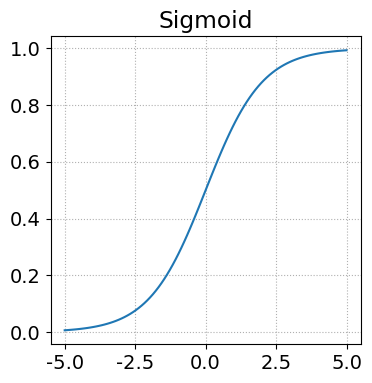

In [ ]:

x = np.linspace(-5, 5, 100)

def sigmoid(x):
    y = 1/(1 + np.exp(-x))
    return y
y = sigmoid(x)

# torch class
# torch_simoid = nn.Sigmoid()
# y = torch_simoid(torch.tensor(x))
# y = F.sigmoid(torch.tensor(x))

activation_plot(x, y, "Sigmoid")

### Tanh (Hyperbolic Tangent)

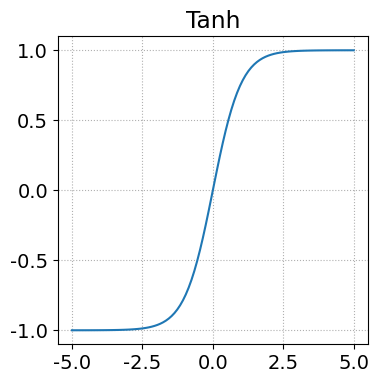

In [ ]:
def tanh(x):
    y = np.tanh(x)
    # y = (np.exp(x) - np.exp(-x))/ (np.exp(x) + np.exp(-x))
    return y
y = tanh(x)

# torch
# torch_tanh = nn.Tanh()
# y = torch_tanh(torch.tensor(x))
# y = F.tanh(torch.tensor(x))

activation_plot(x, y, "Tanh")

### ReLU (Rectified Linear Unit)

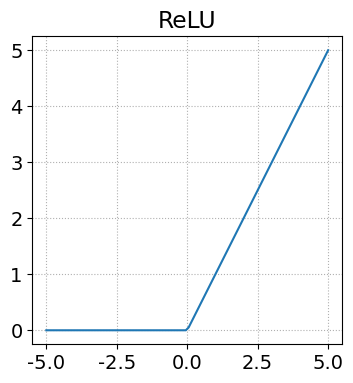

In [ ]:
def relu(x):
    y = np.maximum(0, x)
    return y

# torch
# torch_relu = nn.ReLU()
# y = torch_relu(torch.tensor(x))
# y = F.relu(torch.tensor(x))

y = relu(x)
activation_plot(x, y, "ReLU")

### Leaky ReLU

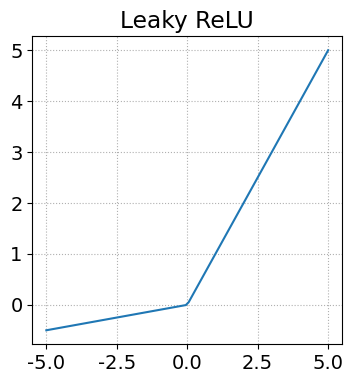

In [ ]:

def leakyRelu(x, alpha:float):
    y = np.where(x > 0, x, alpha*x)
    # y = np.maximum(alpha*x, x)
    return y
y = leakyRelu(x, 0.1)

# torch
# torch_lrelu = nn.LeakyReLU(0.1)
# y = torch_lrelu(torch.tensor(x))
# y = F.leaky_relu(torch.tensor(x), 0.1)


activation_plot(x, y, "Leaky ReLU")

### ELU

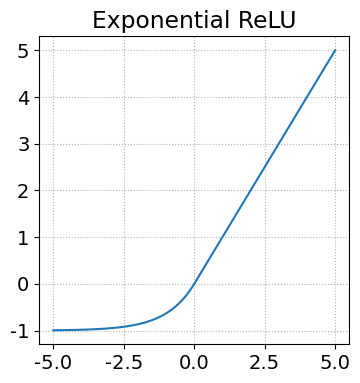

In [ ]:

def ELU(x, alpha):
    y = np.where(x > 0, x, alpha*(np.exp(x) - 1))
    # y = (x>0)*x + (x <= 0)*(alpha*(np.exp(x) - 1))
    return y

y = ELU(x, 1.)

# torch
torch_relu = nn.ELU(0.1)
# y = torch_relu(torch.tensor(x))
# y = F.leaky_relu(torch.tensor(x), 0.1)

activation_plot(x, y, "Exponential ReLU")

### Perceptron class 구현

In [ ]:
class Perceptron:
    def __init__(self, x, nodes = 1):
        
        if not isinstance(x, np.ndarray):
            raise TypeError("Input must be a NumPy array.")
        if x.ndim < 2:
            x = x[np.newaxis, :] #1차원 벡터는 에러 발생하므로, 차원 수 1개 추가

        self.x = x
        self.nodes = nodes


    def neuron(self):
        m, n = self.x.shape 
        w = np.random.randn(self.nodes, n)
        b = np.random.rand(m)
        y = np.dot(w, x.T) + b # .T 는 편하게 행렬을 계산위해 사용

        return y, w, b
    
    def activation(self, x, type: str = "relu"):
        if type == "sigmoid":
            y = 1/(1 + np.exp(-x))            
        
        elif type == "relu":
            y = np.maximum(0, x)
        
        return y
 
x = np.array([[1, 2, 3],
              [4, 5, 6]])


perceptron = Perceptron(x)
output1, w, b = perceptron.neuron()
output2 = perceptron.activation(output1)

print("input = \n", x)
print("w = \n", w)
print("b = \n", b)

print("Before activation = \n", output1)
print("After activation = \n", output2)

input = 
 [[1 2 3]
 [4 5 6]]
w = 
 [[ 0.5606 -1.1501 -0.3844]]
b = 
 [0.8707 0.1718]
Before activation = 
 [[-2.0219 -5.6423]]
After activation = 
 [[0. 0.]]


## 3. Fully connected layer 구현
- MNIST를 활용한 숫자 인식

In [ ]:

# 디바이스 할당
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") # GPU 이용 가능한 장치면 GPU를 사용하고, 아니면 CPU 사용해서 연산 수행.
print(device)

cuda:0


In [149]:
# 다운로드받을 디렉터리명
data_root = './data'

# 디렉터리가 없을 경우 디렉터리 생성
if not os.path.isdir(data_root):
    os.makedirs(data_root, exist_ok=True)

mnist_data = datasets.MNIST(
    # 원본 데이터를 다운로드받을 디렉터리 지정
    root = data_root,  
    # 훈련 데이터인지 또는 검증 데이터인지
    train = True,  
    # 원본 데이터가 없는 경우, 다운로드를 실행하는지 여부
    download = True)

In [134]:
# 데이터 건수 확인
print("mnist_data 타입:", type(mnist_data))
print("mnist_data : \n", mnist_data)
print('데이터 건수: ', len(mnist_data))


# 첫번째 요소 가져오기
image, label = mnist_data[0]

# 데이터 타입 확인
print("="*50)
print('입력 데이터 타입 : ', type(image)) # <class 'PIL.Image.Image'>
print('정답 데이터 타입 : ', type(label)) # <class 'int'>

print("max = ", np.array(image).max())
print("min = ", np.array(image).min())

mnist_data 타입: <class 'torchvision.datasets.mnist.MNIST'>
mnist_data : 
 Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
데이터 건수:  60000
입력 데이터 타입 :  <class 'PIL.Image.Image'>
정답 데이터 타입 :  <class 'int'>
max =  255
min =  0


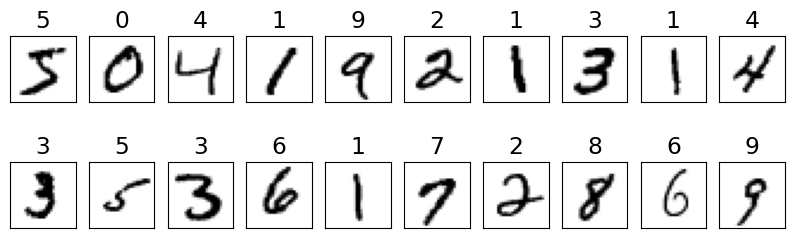

In [ ]:
# 정답 데이터와 함께 처음 20개 데이터를 이미지로 출력

plt.figure(figsize=(10, 3))
for i in range(20):
    ax = plt.subplot(2, 10, i + 1)
    
    # image와 label 취득
    image, label = mnist_data[i]
    
    # 이미지 출력
    plt.imshow(image, cmap='gray_r') # cmap 속성 주여야 흑백으로 출력
    ax.set_title(f'{label}')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

In [ ]:
transform = transforms.Compose([
    
    # (1) 데이터를 텐서로 변환
    transforms.ToTensor(),
    
    # (2) 데이터 정규화
    # transforms.Normalize(0.5, 0.5),
    
    # (3) 1계 텐서로 변환
    transforms.Lambda(lambda x: torch.flatten(x)), # 평탄화
])


# 훈련용 데이터셋 정의
train_set = datasets.MNIST( 
    root = data_root, 
    train = True,
    download = True, 
    transform = transform)

# 검증용 데이터셋 정의
test_set = datasets.MNIST(
    root = data_root, 
    train = False, 
    download = True, 
    transform = transform)

In [152]:
# 변환 결과 확인

image, label = train_set[0]
print('입력 데이터 타입 : ', type(image)) # <class 'torch.Tensor'>
print('입력 데이터 shape : ', image.shape)
print('최솟값 : ', image.data.min())
print('최댓값 : ', image.data.max())

입력 데이터 타입 :  <class 'torch.Tensor'>
입력 데이터 shape :  torch.Size([784])
최솟값 :  tensor(0.)
최댓값 :  tensor(1.)


In [ ]:
# 라이브러리 임포트
from torch.utils.data import DataLoader

# 미니 배치 사이즈 지정
batch_size = 500 # 데이터 처리 사이즈 지정


# 훈련용이므로, 셔플을 적용함
train_loader = DataLoader(
    dataset = train_set, 
    batch_size = batch_size, 
    shuffle = True)

# 검증용 데이터로더
# 검증시에는 셔플을 필요로하지 않음
test_loader = DataLoader(
    dataset = test_set,  
    batch_size = batch_size, 
    shuffle = False)

In [ ]:
# 모델 정의
# 입력 차원수
# 주석: 예를 들어, MNIST 데이터셋에서 28x28 픽셀 이미지를 평탄화(flatten)한 크기입니다.
n_input = 784

# 출력 차원수
# 분류 클래스 수는 10
# 주석: 분류해야 할 클래스(예: 숫자 0부터 9까지)의 개수입니다.
n_output = 10

# 은닉층의 노드 수
n_hidden = 128 # 은닉층의 노드 수는 정해진 것은 없기 때문에 자유롭게 변경

# 결과 확인
print(f'n_input: {n_input}  n_hidden: {n_hidden} n_output: {n_output}')

class Net(nn.Module):
    # PyTorch 모델을 정의하기 위해 nn.Module을 상속받습니다.
    def __init__(self, n_input, n_output, n_hidden):
        # 부모 클래스(nn.Module)의 생성자를 호출하여 초기화합니다.
        super().__init__()

        # 은닉층 정의(은닉층 노드 수 : n_hidden)
        # nn.Linear는 선형 변환 (y = x * W^T + b)을 수행하는 모듈입니다.
        # 입력 크기는 n_input, 출력 크기(은닉층 노드 수)는 n_hidden입니다.
        self.l1 = nn.Linear(n_input, n_hidden)

        # 출력층 정의
        # 입력 크기는 이전 은닉층의 출력 크기인 n_hidden, 최종 출력 크기는 n_output입니다.
        self.l2 = nn.Linear(n_hidden, n_output)

        # ReLU 함수 정의
        # ReLU는 max(0, z)를 계산하는 비선형 활성화 함수입니다.
        # inplace=True는 메모리를 절약하기 위해 입력 x를 직접 수정하도록 설정합니다.
        self.relu = nn.ReLU(inplace=True)
   
   # 모델의 순전파(Forward Pass) 계산을 정의하는 메서드입니다.
    def forward(self, x):
        # 1. 첫 번째 선형 계층(l1)을 통과: x1 = x * W_1^T + b_1
        x1 = self.l1(x)
        # 2. ReLU 활성화 함수 적용: x2 = ReLU(x1)
        x2 = self.relu(x1)
        # 3. 두 번째 선형 계층(출력층, l2)을 통과: x3 = x2 * W_2^T + b_2
        x3 = self.l2(x2)
        
        return x3

In [ ]:

# 모델 인스턴스 생성
net = Net(n_input, n_output, n_hidden)

# 모델을 GPU로 전송
net = net.to(device)
# next(net.parameters()).is_cuda

n_input: 784  n_hidden: 128 n_output: 10


In [ ]:
import torch.optim.lr_scheduler as lr_scheduler

# 학습률
lr = 0.01

# 모델 초기화
net = Net(n_input, n_output, n_hidden).to(device)

# 손실 함수： 교차 엔트로피 함수
# MSE(회귀분석), BCE(0 또는 1 의 2가지 경우), CE(여러 경우의 수)
criterion = nn.CrossEntropyLoss()

# 최적화 함수: 경사 하강법
optimizer = optim.SGD(net.parameters(), lr=lr)

# 반복 횟수
# num_epochs = 100
# 지정한 횟수만큼 학습을 반복 수행. 데이터셋 종류에 따라 다르게 지정.
num_epochs = 10


# 평가 결과 기록
history = np.zeros((0,5))

# scheduler = lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [ ]:
# tqdm 라이브러리 임포트
from tqdm.notebook import tqdm

# 반복 계산 메인 루프
for epoch in range(num_epochs):
    train_acc, train_loss = 0, 0
    val_acc, val_loss = 0, 0

    net.train() # net을 학습하도록 명시적으로 작성
    
    # 훈련 페이즈
    for inputs, labels in tqdm(train_loader):

        # GPU로 전송
        inputs = inputs.to(device)
        labels = labels.to(device)
    
        # 경사 초기화
        optimizer.zero_grad() # optimizer 초기화는 반드시 수행

        # 예측 계산
        outputs = net(inputs)

        # 손실 계산
        loss = criterion(outputs, labels) # 예측 값과 실제 값을 넣어 손실 계산

        # 경사 계산
        loss.backward()
    
        # 파라미터 수정
        optimizer.step()

        # 예측 라벨 산출
        predicted = torch.max(outputs, 1)[1]

        # 손실과 정확도 계산
        train_loss += loss.item()
        train_acc += (predicted == labels).float().mean().item() # 각각의 예측 값과 실제 값의 일치 여부 평균

    # scheduler.step()
    # 예측 페이즈
    net.eval()

    with torch.no_grad():
        for inputs_test, labels_test in test_loader:

            inputs_test = inputs_test.to(device)
            labels_test = labels_test.to(device)

                
            # 예측 계산
            outputs_test = net(inputs_test)

            # 손실 계산
            loss_test = criterion(outputs_test, labels_test)

            # 예측 라벨 산출
            predicted_test = torch.max(outputs_test, 1)[1]

            # 손실과 정확도 계산
            val_loss +=  loss_test.item()
            val_acc +=  (predicted_test == labels_test).float().mean().item()

    # 평가 결과 산출, 기록
    train_acc = train_acc /len(train_loader)
    val_acc = val_acc / len(test_loader)
    train_loss = train_loss /len(train_loader)
    val_loss = val_loss /len(test_loader)
    # current_lr = optimizer.param_groups[0]['lr']
    print (f'Epoch: {epoch}, loss: {train_loss:.5f} acc: {train_acc:.5f} val_loss: {val_loss:.5f}, val_acc: {val_acc:.5f}')
    item = np.array([epoch , train_loss, train_acc, val_loss, val_acc])
    # print(f"lr = {current_lr}")
    history = np.vstack((history, item))

## 4. Convolutional neural network 구현
- CIFAR 자료를 활용한 CNN 분석

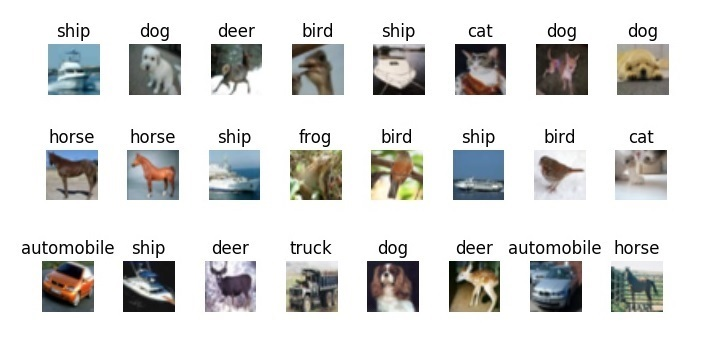

In [168]:
Image('../fig/cifar.jpg')

In [ ]:
transform_cnn = transforms.Compose([
    # (1) 데이터를 텐서로 변환
    transforms.ToTensor(),
     # (2) 데이터 정규화
    transforms.Normalize(0.5, 0.5),
])

# 훈련 데이터셋 (3계 텐서 버전)
train_set = datasets.CIFAR10(
    root =  data_root, 
    train = True, 
    download = True, 
    transform = transform_cnn)

# 검증 데이터셋 (3계 텐서 버전)
test_set = datasets.CIFAR10(
    root = data_root, 
    train = False, 
    download = True, 
    transform = transform_cnn)

print(net.avgpool)

100%|██████████| 170M/170M [00:27<00:00, 6.25MB/s] 


In [169]:
# 훈련용 데이터로더
# 훈련용이므로 셔플을 True로 설정
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)

# 검증용 데이터로더
# 검증용이므로 셔플하지 않음
test_loader = DataLoader(test_set,  batch_size=batch_size, shuffle=False) 

In [ ]:
# 정답 라벨 정의
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [ ]:
class CNN(nn.Module):
  # PyTorch 모델을 정의하기 위해 nn.Module을 상속받습니다.
  # n_output: 최종 분류 클래스 수, n_hidden: 선형층의 은닉 노드 수
  def __init__(self, n_output, n_hidden):
    # 부모 클래스(nn.Module)의 생성자를 호출하여 초기화합니다.
    super().__init__()
    # 합성곱 층 (Convolutional Layer) 정의
    # nn.Conv2d(입력 채널, 출력 채널, 커널 크기)
    # 3 (RGB 이미지 채널 수) -> 32개의 특징 맵, 커널 크기는 3x3 (기본 stride=1, padding=0)
    self.conv1 = nn.Conv2d(3, 32, 3)
    # 32 (이전 층의 출력 채널) -> 32개의 특징 맵, 커널 크기는 3x3
    self.conv2 = nn.Conv2d(32, 32, 3)

    # 활성화 함수 (Activation Function) 및 풀링(Pooling) 정의
    # ReLU: max(0, z) 비선형 함수. inplace=True는 메모리 절약을 위해 입력 텐서를 직접 수정합니다.
    self.relu = nn.ReLU(inplace=True)
    # Max Pooling: (2x2) 크기의 필터로 최대값을 추출하여 특징 맵 크기를 절반으로 줄입니다.
    self.maxpool = nn.MaxPool2d((2,2))
    # 3. 평탄화(Flatten) 정의
    # CNN의 특징 추출 부분(self.features)과 분류 부분(self.classifier)을 연결하기 위해 사용됩니다.
    self.flatten = nn.Flatten()
    # 분류기(Classifier)의 선형 층 정의
    # 첫 번째 선형층: 입력 크기는 6272, 출력 크기는 n_hidden입니다.
    # 주석: 6272는 입력 이미지 크기(예: 32x32)와 위의 합성곱 및 풀링 연산을 고려하여 수동으로 계산된 값입니다.
    # 예를 들어, 32x32 입력 시: (32-3+1) -> 30x30 -> (30-3+1) -> 28x28 -> (28/2) -> 14x14.
    # 14 * 14 * 32 (채널) = 6272
    self.l1 = nn.Linear(6272, n_hidden)
    # 출력층: n_hidden -> n_output (최종 클래스 수)
    self.l2 = nn.Linear(n_hidden, n_output)

    # 특징 추출 부분(Feature Extraction)을 nn.Sequential로 묶어 정의
    # 이미지에서 특징을 추출하는 합성곱 및 풀링 계층들을 순서대로 배열합니다.
    self.features = nn.Sequential(
        self.conv1,
        self.relu,
        self.conv2,
        self.relu,
        self.maxpool)
    # 분류 부분(Classifier)을 nn.Sequential로 묶어 정의
    # 추출된 특징(평탄화된 벡터)을 사용하여 최종 분류 로짓(logits)을 계산합니다.
    self.classifier = nn.Sequential(
       self.l1,
       self.relu,
       self.l2)

  # 모델의 순전파(Forward Pass) 계산을 정의하는 메서드입니다.
  def forward(self, x):
    x1 = self.features(x)
    x2 = self.flatten(x1)
    x3 = self.classifier(x2)
    return x3     

In [171]:
# 모델 인스턴스 생성
net = CNN(n_output, n_hidden).to(device)

# 손실 함수： 교차 엔트로피 함수
criterion = nn.CrossEntropyLoss()

# 학습률
lr = 0.01

# 최적화 함수: 경사 하강법
optimizer = torch.optim.SGD(net.parameters(), lr=lr)


# 반복 횟수
num_epochs = 10

In [ ]:
# tqdm 라이브러리 임포트
from tqdm.notebook import tqdm

# 반복 계산 메인 루프
for epoch in range(num_epochs):
    train_acc, train_loss = 0, 0
    val_acc, val_loss = 0, 0

    net.train()
    # 훈련 페이즈
    for inputs, labels in tqdm(train_loader):

        # GPU로 전송
        inputs = inputs.to(device)
        labels = labels.to(device)
    
        # 경사 초기화
        optimizer.zero_grad()

        # 예측 계산
        outputs = net(inputs)

        # 손실 계산
        loss = criterion(outputs, labels)

        # 경사 계산
        loss.backward()
    
        # 파라미터 수정
        optimizer.step()

        # 예측 라벨 산출
        predicted = torch.max(outputs, 1)[1]

        # 손실과 정확도 계산
        train_loss += loss.item()
        train_acc += (predicted == labels).float().mean().item()

    # scheduler.step()
    # 예측 페이즈
    net.eval()

    with torch.no_grad():
        for inputs_test, labels_test in test_loader:

            inputs_test = inputs_test.to(device)
            labels_test = labels_test.to(device)
                
            # 예측 계산
            outputs_test = net(inputs_test)

            # 손실 계산
            loss_test = criterion(outputs_test, labels_test)

            # 예측 라벨 산출
            predicted_test = torch.max(outputs_test, 1)[1]

            # 손실과 정확도 계산
            val_loss +=  loss_test.item()
            val_acc +=  (predicted_test == labels_test).float().mean().item()

    # 평가 결과 산출, 기록
    train_acc = train_acc /len(train_loader)
    val_acc = val_acc / len(test_loader)
    train_loss = train_loss /len(train_loader)
    val_loss = val_loss /len(test_loader)
    # current_lr = optimizer.param_groups[0]['lr']
    print (f'Epoch: {epoch}, loss: {train_loss:.5f} acc: {train_acc:.5f} val_loss: {val_loss:.5f}, val_acc: {val_acc:.5f}')
    item = np.array([epoch , train_loss, train_acc, val_loss, val_acc])
    # print(f"lr = {current_lr}")
    history = np.vstack((history, item))

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 0, loss: 2.27847 acc: 0.14788 val_loss: 2.24004, val_acc: 0.22920


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 1, loss: 2.16489 acc: 0.26976 val_loss: 2.07100, val_acc: 0.29450


  0%|          | 0/100 [00:00<?, ?it/s]

...

Epoch: 7, loss: 1.70628 acc: 0.40660 val_loss: 1.68383, val_acc: 0.41380


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 8, loss: 1.66243 acc: 0.42034 val_loss: 1.63674, val_acc: 0.42890


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 9, loss: 1.61744 acc: 0.43590 val_loss: 1.59372, val_acc: 0.43930
